# Notebook to manually verfiy test accuracy

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
PHENOTYPES_SUBSET = [
    "Alanine",
    "Arginine",
    "Cellobiose",
    "Fructose",
    "Galactose",
    "Galacturonic-Acid",
    "Glucose",
    "Glycerol",
    "Histidine",
    "Maltose",
    "Mannitol",
    "Mannose",
    "Serine",
    "Sucrose",
    "Trehalose",
    "m-Inositol",
]

## Verification of training on ATLeaf and testing on Lit data

In [3]:
# features_folder = Path("../data/interim/features/")
features_folder = Path("../data/processed/features_reduced/")
# features_folder_atleaf = features_folder / "atleaf/kofam.tsv"
# features_folder_lit = features_folder / "lit/kofam.tsv"
features_folder_atleaf = features_folder / "atleaf/uniref90/uniref90.tsv"
features_folder_lit = features_folder / "lit/uniref90/uniref90.tsv"

In [4]:
phenotypes_folder = Path("../data/processed/phenotypes/")
phenotypes_folder_atleaf = phenotypes_folder / "atleaf"
phenotypes_folder_lit = phenotypes_folder / "lit"

In [5]:
DTYPE = {"genomeID": str}
features_atleaf_raw = pd.read_csv(
    features_folder_atleaf, sep="\t", index_col=0, dtype=DTYPE
).astype(int)
features_lit_raw = pd.read_csv(
    features_folder_lit, sep="\t", index_col=0, dtype=DTYPE
).astype(int)

In [6]:
def read_phenotypes(folder: Path) -> dict[str, pd.Series]:
    phenotype_dict = {}
    for phenotype_file in folder.glob("*.tsv"):
        data = (
            pd.read_csv(phenotype_file, sep="\t", index_col=0, dtype={"genomeID": str})
            .dropna()
            .astype(int)
        )
        phenotype_dict[phenotype_file.stem] = data.iloc[:, 0]
    return phenotype_dict

In [7]:
phenotypes_atleaf_dict = read_phenotypes(phenotypes_folder_atleaf)
phenotypes_lit_dict = read_phenotypes(phenotypes_folder_lit)

## Validation scores on atleaf and lit

In [8]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, matthews_corrcoef

In [9]:
def _process_data(
    X_raw: pd.DataFrame, y_raw: pd.Series
) -> tuple[pd.DataFrame, pd.Series]:
    y_ind = y_raw.index
    common_ind = X_raw.index.intersection(y_ind)
    return X_raw.loc[common_ind], y_raw.loc[common_ind]

In [10]:
def perform_cv(X_raw: pd.DataFrame, y_raw: pd.Series) -> pd.DataFrame:
    X, y = _process_data(X_raw, y_raw)
    # NOTE: Increase the number of estimators to get better results
    model = RandomForestClassifier(n_estimators=1_000, random_state=0)
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kfold,
        scoring=("accuracy", "balanced_accuracy", "matthews_corrcoef"),
    )
    test_accuracy_scores = cv_results["test_accuracy"]
    test_balanced_accuracy_scores = cv_results["test_balanced_accuracy"]
    test_mcc_scores = cv_results["test_matthews_corrcoef"]
    scores = {
        "acc": test_accuracy_scores,
        "bacc": test_balanced_accuracy_scores,
        "mcc": test_mcc_scores,
        "fold": list(range(0, 5)),
    }
    score_df = pd.DataFrame(scores)
    return score_df

In [11]:
def calculate_cv_results(
    features: pd.DataFrame,
    phenotypes_dict: dict[str, pd.Series],
    phenotypes_subset: list[str],
) -> pd.DataFrame:
    data = []
    for phenotype_name in phenotypes_subset:
        cv_results = perform_cv(features, phenotypes_dict[phenotype_name])
        cv_results["phenotype"] = phenotype_name
        data.append(cv_results)
    return pd.concat(data)

In [12]:
cv_results_atleaf = calculate_cv_results(
    features_atleaf_raw, phenotypes_atleaf_dict, PHENOTYPES_SUBSET
)
cv_results_lit = calculate_cv_results(
    features_lit_raw, phenotypes_lit_dict, PHENOTYPES_SUBSET
)

In [13]:
cv_results_atleaf["dataset"] = "atleaf"
cv_results_lit["dataset"] = "lit"
cv_results = pd.concat([cv_results_atleaf, cv_results_lit])

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


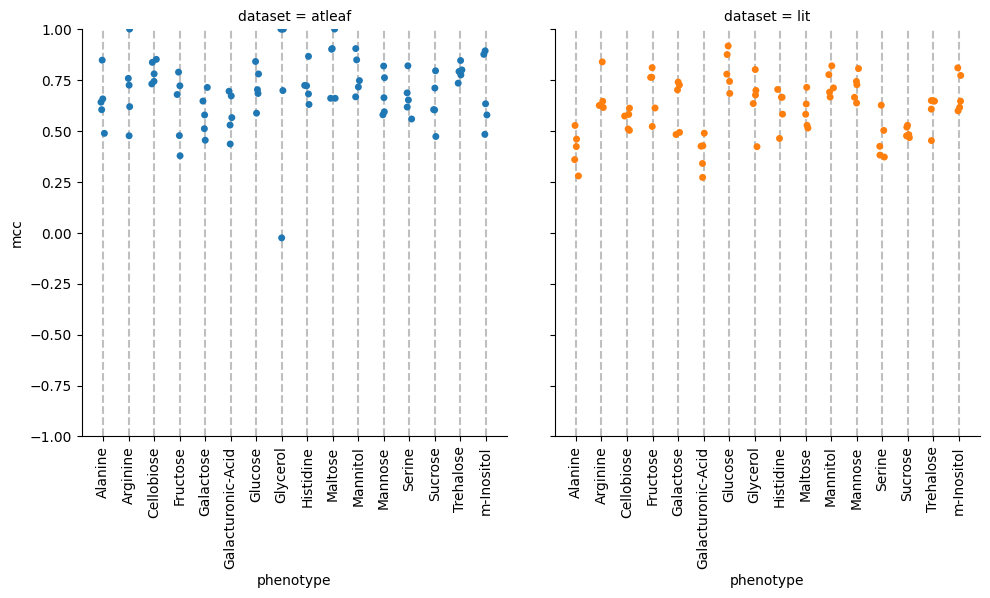

In [15]:
g = sns.catplot(
    data=cv_results, x="phenotype", y="mcc", kind="strip", col="dataset", hue="dataset"
)
# rotate the x-axis labels
for ax in g.axes.flat:
    ax.set_ylim(-1, 1)
    # draw vertical lines at every x-axis tick
    xticks = ax.get_xticks()
    ymin, ymax = ax.get_ylim()
    ax.vlines(x=xticks, ymin=ymin, ymax=ymax, color="gray", linestyle="--", alpha=0.5)
    ax.tick_params(axis="x", labelrotation=90)

### Calculate test scores

In [16]:
nonzero_features_lit = features_lit_raw.sum(axis=0) != 0
features_lit_filt = features_lit_raw.loc[:, nonzero_features_lit]
nonzero_features_atleaf = features_atleaf_raw.sum(axis=0) != 0
features_atleaf_filt = features_atleaf_raw.loc[:, nonzero_features_atleaf]

In [17]:
features_atleaf_lit = (
    pd.concat([features_atleaf_filt, features_lit_filt], axis=0, join="inner")
    .fillna(0)
    .astype(int)
)
features_atleaf_lit

,UniRef90_Q82DN5,UniRef90_A0A0M3D3R2,UniRef90_Q87Y59,UniRef90_A0A0F4U1F8,UniRef90_Q88MY7,UniRef90_A4VGK4,UniRef90_A0A0D5Y6F3,UniRef90_A0A0B7D5X0,UniRef90_Q885R6,UniRef90_A0A5E6VG50,...,UniRef90_A1VJN4,UniRef90_A0A0D7KDE1,UniRef90_A0A7X0PMA2,UniRef90_A0A3M2ZFX6,UniRef90_F2K8N8,UniRef90_A0A072ZR91,UniRef90_A0JSD3,UniRef90_UPI001F3CFB92,UniRef90_A0A1I4T9A7,UniRef90_A0A379J522
genomeID,,,,,,,,,,,,,,,,,,,,,
GCF_001423125.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_001422605.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_001421785.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_001423365.1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_001421415.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32008.570,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
630.44,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
202950.11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
features_atleaf = features_atleaf_lit.loc[features_atleaf_raw.index]
features_lit = features_atleaf_lit.loc[features_lit_raw.index]

In [19]:
features_atleaf.shape, features_lit.shape

((206, 77), (362, 77))

In [20]:
def perform_train_test(
    train_X_raw, train_y_raw, test_X_raw, test_y_raw
) -> pd.DataFrame:
    train_X, train_y = _process_data(train_X_raw, train_y_raw)
    test_X, test_y = _process_data(test_X_raw, test_y_raw)
    model = RandomForestClassifier(n_estimators=1_000, random_state=0)
    model.fit(train_X, train_y)
    data = []
    for i in range(5):
        subset_ind = np.random.choice(test_X.shape[0], size=150, replace=False)
        test_X_subset = test_X.iloc[subset_ind, :]
        test_y_subset = test_y.iloc[subset_ind]
        pred_y = model.predict(test_X_subset)
        acc = accuracy_score(test_y_subset, pred_y)
        bacc = balanced_accuracy_score(test_y_subset, pred_y)
        mcc = matthews_corrcoef(test_y_subset, pred_y)
        scores = {"acc": acc, "bacc": bacc, "mcc": mcc, "fold": i}
        data.append(scores)
    return pd.DataFrame(data)

In [21]:
perform_train_test(
    features_atleaf,
    phenotypes_atleaf_dict["Alanine"],
    features_lit,
    phenotypes_lit_dict["Alanine"],
)

,acc,bacc,mcc,fold
0,0.466667,0.572727,0.139495,0
1,0.433333,0.571484,0.130080,1
2,0.493333,0.608553,0.202419,2
3,0.506667,0.638509,0.249823,3
4,0.493333,0.600146,0.179744,4


In [22]:
def calculate_test_results(
    train_features: pd.DataFrame,
    train_phenotypes_dict: dict[str, pd.Series],
    test_features: pd.DataFrame,
    test_phenotypes_dict: dict[str, pd.Series],
    phenotypes_subset: list[str],
) -> pd.DataFrame:
    data = []
    for phenotype_name in phenotypes_subset:
        test_results = perform_train_test(
            train_features,
            train_phenotypes_dict[phenotype_name],
            test_features,
            test_phenotypes_dict[phenotype_name],
        )
        test_results["phenotype"] = phenotype_name
        data.append(test_results)
    return pd.concat(data)

In [23]:
test_atleaf_lit = calculate_test_results(
    features_atleaf,
    phenotypes_atleaf_dict,
    features_lit,
    phenotypes_lit_dict,
    PHENOTYPES_SUBSET,
)
test_lit_atleaf = calculate_test_results(
    features_lit,
    phenotypes_lit_dict,
    features_atleaf,
    phenotypes_atleaf_dict,
    PHENOTYPES_SUBSET,
)

In [24]:
test_atleaf_lit["train"] = "atleaf"
test_atleaf_lit["test"] = "lit"
test_lit_atleaf["train"] = "lit"
test_lit_atleaf["test"] = "atleaf"
test_results = pd.concat([test_atleaf_lit, test_lit_atleaf])

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


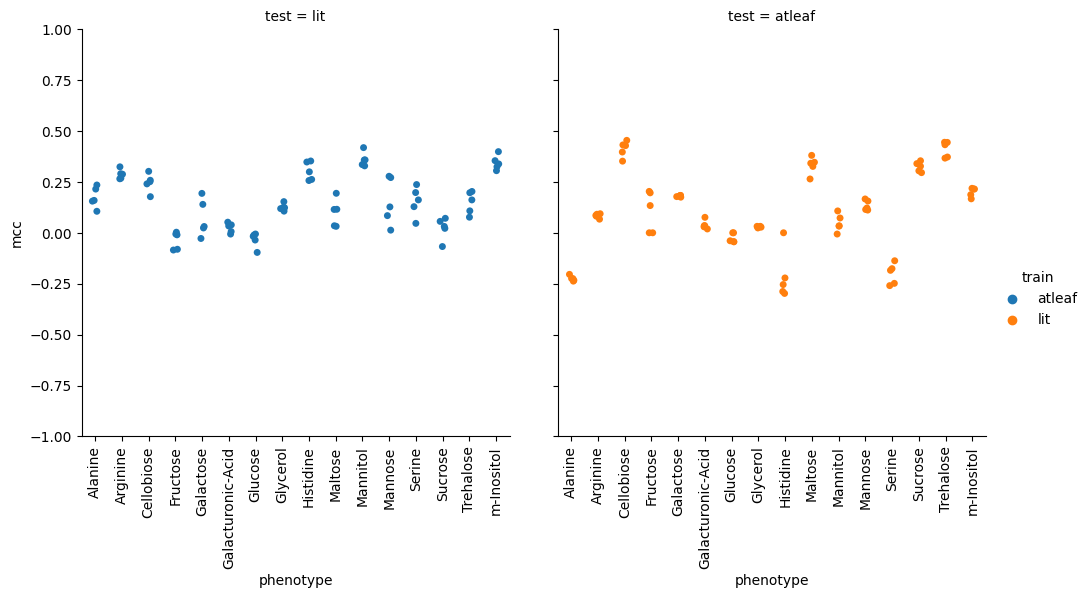

In [25]:
g = sns.catplot(
    data=test_results, x="phenotype", y="mcc", hue="train", kind="strip", col="test"
)
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.tick_params(axis="x", labelrotation=90)